<a href="https://colab.research.google.com/github/hamsabm/AI_RideWise/blob/main/kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 1

Import Required Libraries

In [ ]:
# Import necessary Python libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for consistency
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10,5)


Load Dataset

In [ ]:
# Upload dataset in Colab
from google.colab import files
uploaded = files.upload()   # Select "hour.csv" file

# Read dataset into pandas DataFrame
df = pd.read_csv("hour.csv")


Saving hour.csv to hour (1).csv


Inspect Dataset

In [ ]:
# Display shape and first few rows
print("Shape of dataset:", df.shape)
display(df.head())

# Display datatypes and memory info
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics for numeric columns
print("\nSummary Statistics:")
display(df.describe().T)

# List of all column names
print("\nColumns in dataset:")
print(df.columns.tolist())


Shape of dataset: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

Missing Values:
instant     

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000



Columns in dataset:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


Distribution of Target Variable

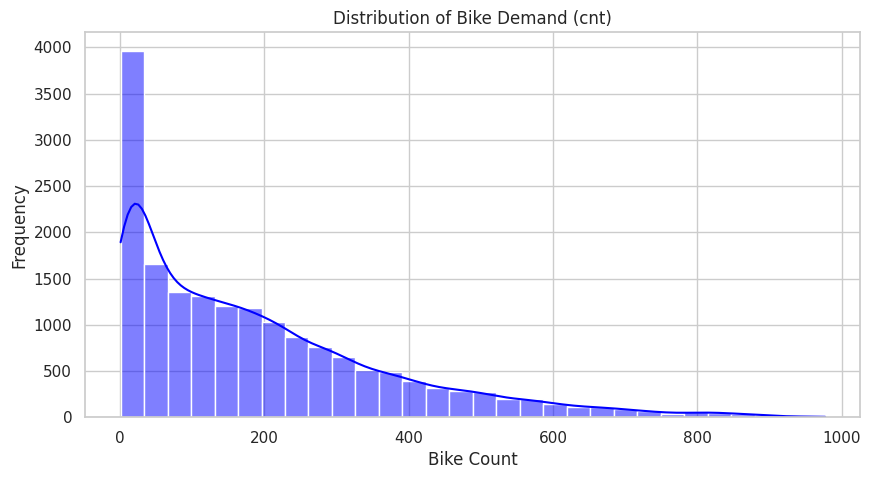

In [ ]:
# Visualize distribution of total bike demand (cnt)
sns.histplot(df['cnt'], bins=30, kde=True, color="blue")
plt.title("Distribution of Bike Demand (cnt)")
plt.xlabel("Bike Count")
plt.ylabel("Frequency")
plt.show()


Demand by Season

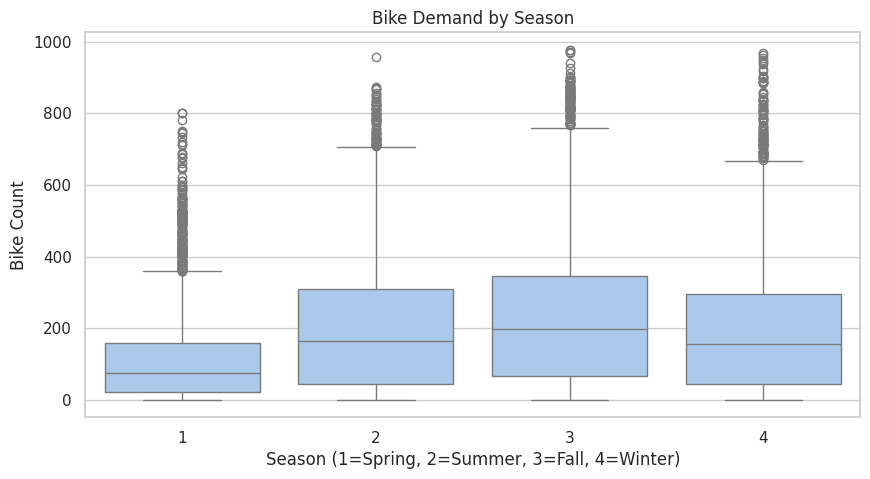

In [ ]:
# Boxplot of demand across seasons
sns.boxplot(x="season", y="cnt", data=df)
plt.title("Bike Demand by Season")
plt.xlabel("Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)")
plt.ylabel("Bike Count")
plt.show()


Demand by Hour

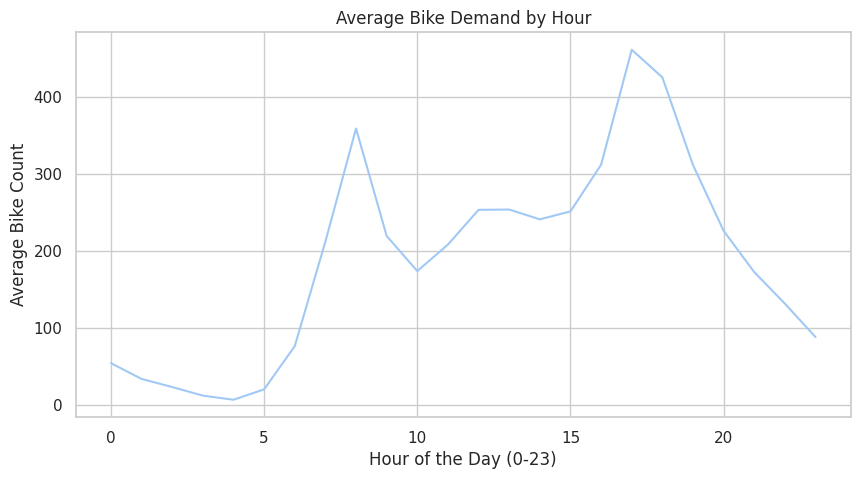

In [ ]:
sns.lineplot(x="hr", y="cnt", data=df, estimator="mean", errorbar=None)
plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Average Bike Count")
plt.show()


Demand by Weekday

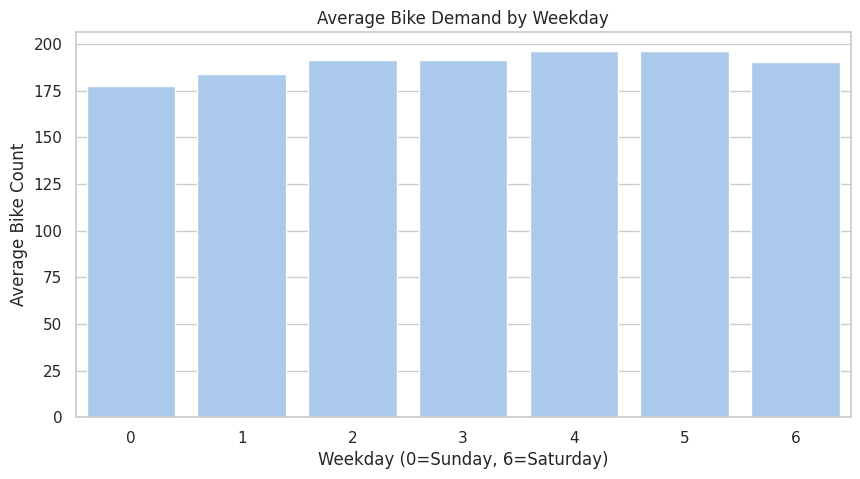

In [ ]:
# Barplot of average demand across weekdays
sns.barplot(x="weekday", y="cnt", data=df, estimator=np.mean, errorbar=None)
plt.title("Average Bike Demand by Weekday")
plt.xlabel("Weekday (0=Sunday, 6=Saturday)")
plt.ylabel("Average Bike Count")
plt.show()


Correlation Heatmap


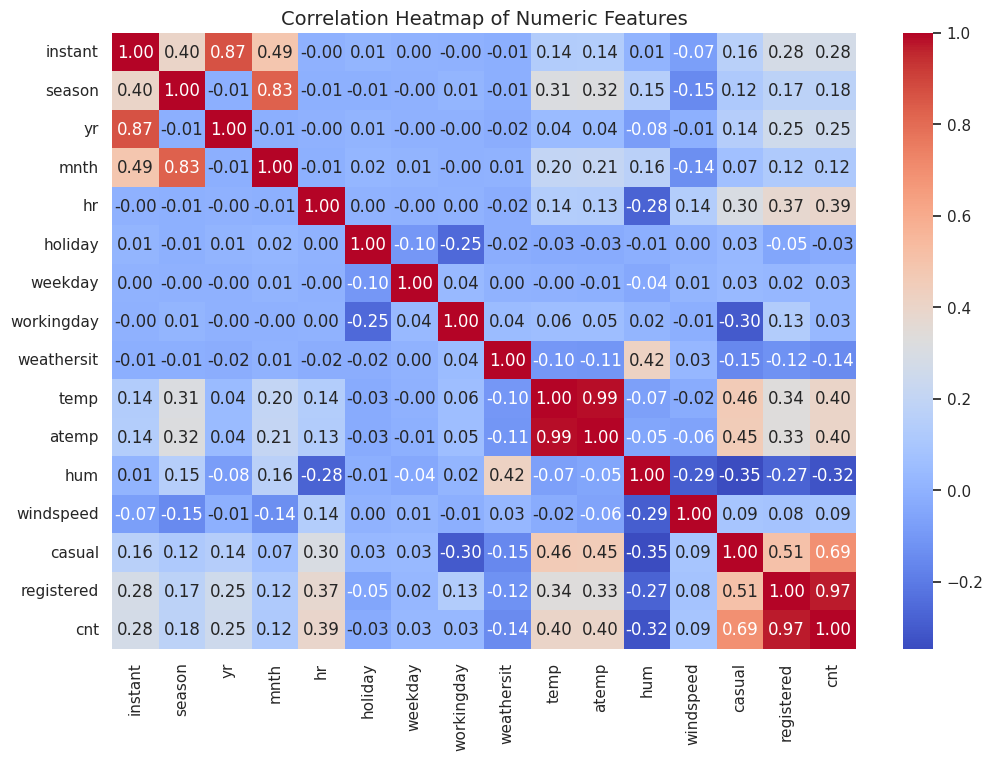

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()


Demand vs Temperature / Humidity / Windspeed

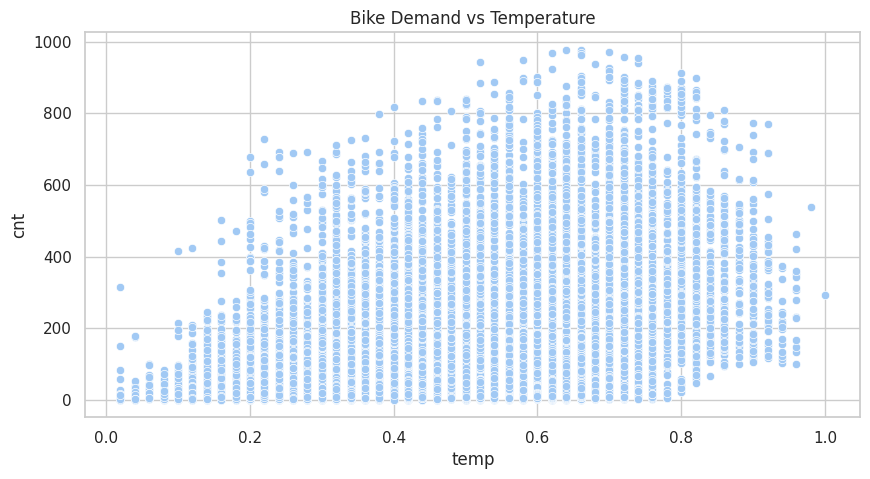

In [ ]:
sns.scatterplot(x="temp", y="cnt", data=df)
plt.title("Bike Demand vs Temperature")
plt.show()


WEEK **2**

Handle Missing Values

In [ ]:
# Check missing values again (for safety)
print("Missing values before cleaning:")
print(df.isnull().sum())

# The Kaggle hour.csv dataset is usually clean,
# but we ensure no issues:
df = df.fillna({
    "temp": df["temp"].median(),
    "atemp": df["atemp"].median(),
    "hum": df["hum"].median(),
    "windspeed": df["windspeed"].median()
})

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing values after cleaning:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Convert Date Column to Datetime

In [ ]:
# Convert dteday to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Extract additional datetime features
df['year'] = df['dteday'].dt.year
df['month'] = df['dteday'].dt.month
df['day'] = df['dteday'].dt.day
df['weekday_new'] = df['dteday'].dt.weekday  # avoid overwriting original weekday


Feature Engineering

In [ ]:
# Weekend indicator
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Peak hours indicator (7–9 AM and 5–7 PM commuting hours)
df['is_peak_hour'] = df['hr'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)

# Drop 'instant' (just row index, not useful)
df = df.drop(['instant'], axis=1)


Encode Categorical Variables

In [ ]:
# Encode season, month, weekday, weather situation as categorical
df = pd.get_dummies(
    df,
    columns=['season', 'mnth', 'weathersit'],
    drop_first=True
)

print("Columns after encoding:")
print(df.columns.tolist())


Columns after encoding:
['dteday', 'yr', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'year', 'month', 'day', 'weekday_new', 'is_weekend', 'is_peak_hour', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weathersit_2', 'weathersit_3', 'weathersit_4']


Scale Continuous Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Features to scale
scale_cols = ['temp','atemp','hum','windspeed']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\nScaled features preview:")
display(df[scale_cols].head())



Scaled features preview:


,temp,atemp,hum,windspeed
0,-1.334648,-1.093281,0.947372,-1.553889
1,-1.438516,-1.181732,0.895539,-1.553889
2,-1.438516,-1.181732,0.895539,-1.553889
3,-1.334648,-1.093281,0.636370,-1.553889
4,-1.334648,-1.093281,0.636370,-1.553889


Define Features and Target

In [ ]:
# Define target variable
y = df['cnt']

# Drop target and leakage columns
X = df.drop(['cnt','casual','registered','dteday'], axis=1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (17379, 32)
Target shape: (17379,)


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (13903, 32)
Test set size: (3476, 32)


WEEK 3 : Preliminary Model Training

Import Libraries

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


Define Evaluation Function

In [ ]:
# Function to evaluate regression models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train model
    model.fit(X_train, y_train)
    # Predictions
    y_pred = model.predict(X_test)
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2


Train and Evaluate Models

In [ ]:
# Dictionary to store results
results = {}

# 1. Linear Regression
lr = LinearRegression()
results['Linear Regression'] = evaluate_model(lr, X_train, y_train, X_test, y_test)

# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
results['Ridge Regression'] = evaluate_model(ridge, X_train, y_train, X_test, y_test)

# 3. Lasso Regression
lasso = Lasso(alpha=0.01)
results['Lasso Regression'] = evaluate_model(lasso, X_train, y_train, X_test, y_test)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
results['Random Forest'] = evaluate_model(rf, X_train, y_train, X_test, y_test)

# 5. XGBoost Regressor
xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
results['XGBoost'] = evaluate_model(xgb, X_train, y_train, X_test, y_test)


Display Results

In [ ]:
# Convert results into DataFrame for comparison
results_df = pd.DataFrame(results, index=['MAE', 'RMSE', 'R2']).T
results_df = results_df.sort_values(by="R2", ascending=False)

print("Model Performance Comparison (Week 3):")
display(results_df)


Model Performance Comparison (Week 3):


,MAE,RMSE,R2
XGBoost,22.401545,36.095899,0.958854
Random Forest,24.007251,40.823772,0.947369
Linear Regression,86.158779,114.509923,0.585904
Ridge Regression,86.159984,114.511940,0.585889
Lasso Regression,86.160813,114.517523,0.585849


Week 4: Predictions and Fine-Tuning

Import Libraries

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Hyperparameter Tuning – Random Forest

In [ ]:
# Define parameter grid for Random Forest (fixed)
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]  # <-- removed "auto"
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=15,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

print("Best Random Forest Parameters:", rf_random.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}


Hyperparameter Tuning (XGBoost)

In [ ]:
# Define parameter grid for XGBoost
xgb_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_params,
    n_iter=15,   # test 15 random combos
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

# Fit
xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_

print("✅ Best XGBoost Parameters:", xgb_random.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
✅ Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
# Train Random Forest with best parameters
best_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None,
    random_state=42
)

best_rf.fit(X_train, y_train)

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print(f"Tuned Random Forest -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")


Tuned Random Forest -> MAE: 24.30, RMSE: 41.01, R²: 0.9469


Evaluate Tuned Models

In [ ]:
# Function for evaluation
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")
    return mae, rmse, r2

# Evaluate tuned models
rf_results = evaluate(best_rf, X_test, y_test, "Tuned Random Forest")
xgb_results = evaluate(best_xgb, X_test, y_test, "Tuned XGBoost")

# Store results
results = {
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R²"]).T
display(results_df)


Tuned Random Forest -> MAE: 24.30, RMSE: 41.01, R²: 0.9469
Tuned XGBoost -> MAE: 21.07, RMSE: 34.83, R²: 0.9617


,MAE,RMSE,R²
Random Forest,24.298520,41.013965,0.946878
XGBoost,21.070147,34.832516,0.961684


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return [mae, rmse, r2]

# Evaluate both tuned models
rf_results = evaluate(best_rf, X_test, y_test, "Random Forest")
xgb_results = evaluate(best_xgb, X_test, y_test, "XGBoost")

# Store results in DataFrame
results_df = pd.DataFrame(
    [rf_results, xgb_results],
    columns=["MAE", "RMSE", "R²"],
    index=["Random Forest", "XGBoost"]
)

print("📊 Tuned Model Comparison")
display(results_df)


📊 Tuned Model Comparison


,MAE,RMSE,R²
Random Forest,24.298520,41.013965,0.946878
XGBoost,21.070147,34.832516,0.961684


Feature Importance (XGBoost)

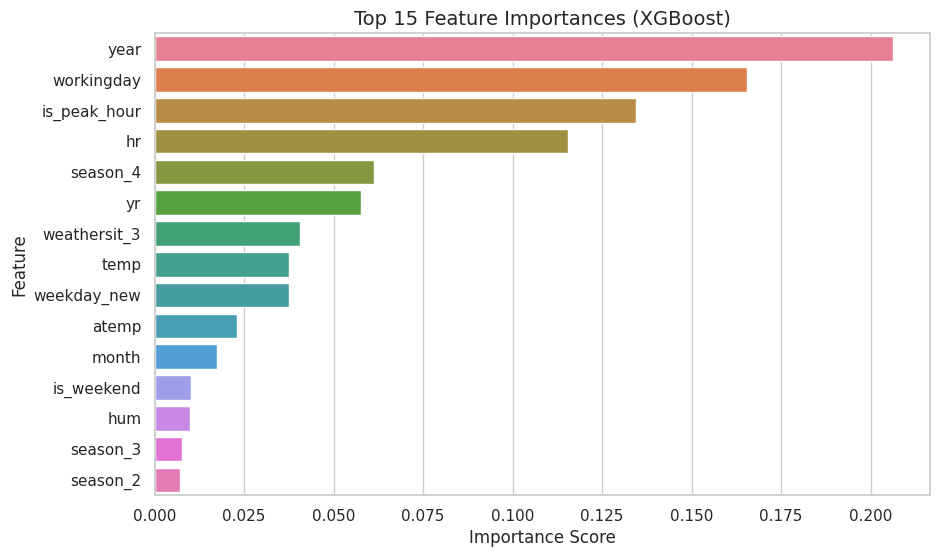

In [ ]:
# Feature Importance from XGBoost
importance = best_xgb.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({"Feature": features, "Importance": importance})
fi_df = fi_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=fi_df, hue="Feature", dodge=False, legend=False)
plt.title("Top 15 Feature Importances (XGBoost)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


COMPARISION

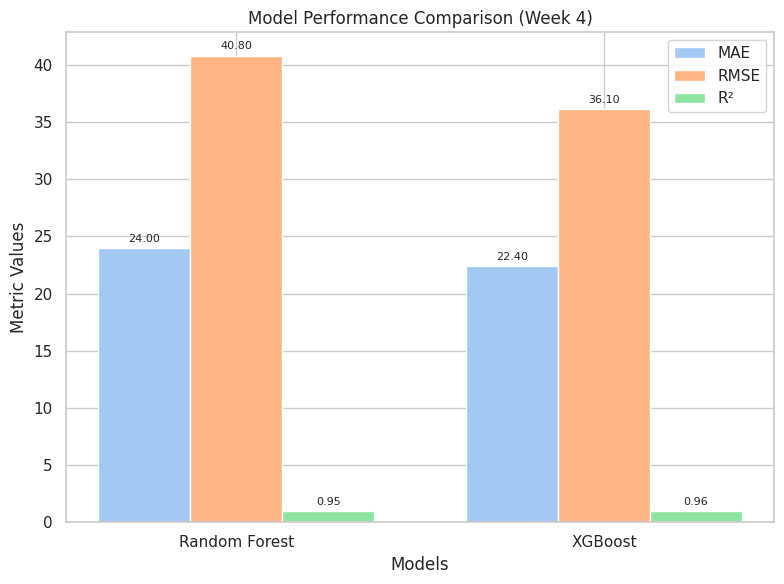

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example results (replace these with actual model outputs from your run)
results = {
    "Random Forest": {"MAE": 24.0, "RMSE": 40.8, "R2": 0.947},
    "XGBoost": {"MAE": 22.4, "RMSE": 36.1, "R2": 0.959}
}

# Convert results into arrays for plotting
models = list(results.keys())
mae = [results[m]["MAE"] for m in models]
rmse = [results[m]["RMSE"] for m in models]
r2 = [results[m]["R2"] for m in models]

x = np.arange(len(models))
width = 0.25

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(8,6))

bar1 = ax.bar(x - width, mae, width, label="MAE")
bar2 = ax.bar(x, rmse, width, label="RMSE")
bar3 = ax.bar(x + width, r2, width, label="R²")

# Labels and formatting
ax.set_xlabel("Models")
ax.set_ylabel("Metric Values")
ax.set_title("Model Performance Comparison (Week 4)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate bars with values
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

annotate_bars(bar1)
annotate_bars(bar2)
annotate_bars(bar3)

plt.tight_layout()
plt.show()


Predictions vs Actuals

Sample of Predictions vs Actuals:


,Actual,Predicted
0,425,408.927734
1,88,95.532341
2,4,10.974161
3,526,525.325195
4,13,31.436378
5,32,32.150486
6,706,716.902954
7,26,45.466827
8,2,8.341342
9,21,26.642452


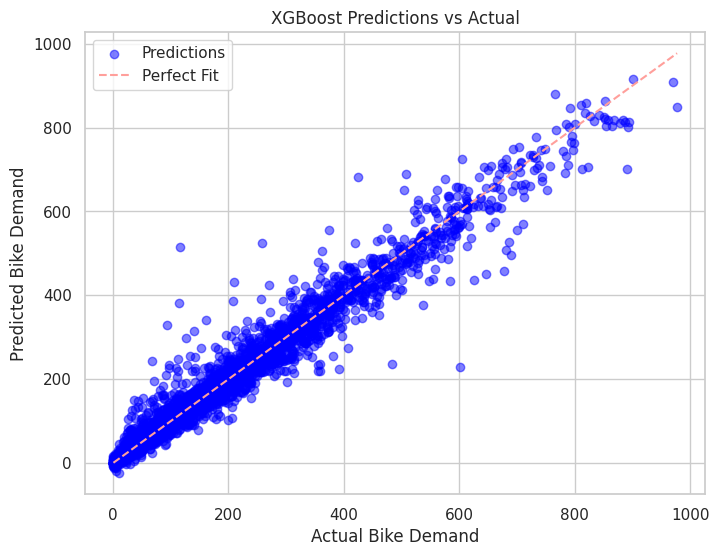

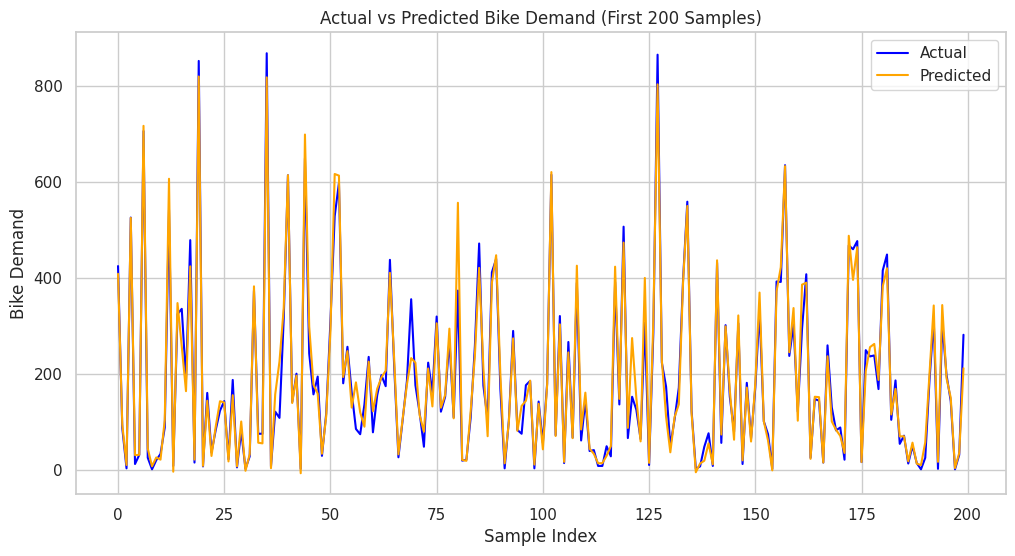

In [ ]:
# Generate predictions using the best XGBoost model
y_pred_final = best_xgb.predict(X_test)

# Create DataFrame for comparison
final_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_final
})

# Show first 10 rows
print("Sample of Predictions vs Actuals:")
display(final_results.head(10))

# Scatter plot (Predicted vs Actual)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_final, alpha=0.5, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
plt.xlabel("Actual Bike Demand")
plt.ylabel("Predicted Bike Demand")
plt.title("XGBoost Predictions vs Actual")
plt.legend()
plt.show()

# Line plot (trend comparison)
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label="Actual", color="blue")
plt.plot(y_pred_final[:200], label="Predicted", color="orange")
plt.title("Actual vs Predicted Bike Demand (First 200 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Bike Demand")
plt.legend()
plt.show()


Week 5: Model Refinement and Experiments

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Additional Feature Engineering

In [ ]:
# Copy dataset to avoid overwriting previous version
df_refined = df.copy()

# Interaction features (example: temp × humidity, since they interact in comfort level)
df_refined['temp_hum_interaction'] = df_refined['temp'] * df_refined['hum']

# Polynomial feature (squared temp – helps capture non-linear relation)
df_refined['temp_squared'] = df_refined['temp'] ** 2

# Lag feature: previous hour’s demand (helps capture short-term trend)
df_refined['lag_cnt'] = df_refined['cnt'].shift(1).fillna(df_refined['cnt'].mean())

# Redefine features (X) and target (y)
y = df_refined['cnt']
X = df_refined.drop(['cnt', 'casual', 'registered', 'dteday'], axis=1)


In [ ]:
Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)


Training Set: (13903, 35)
Test Set: (3476, 35)


Compare Model Performance


📊 Model Comparison (Week 5):


,MAE,RMSE,R²
LightGBM,19.699823,32.042691,0.967576
XGBoost,20.051409,32.761065,0.966105
Random Forest,20.957552,34.696706,0.961982


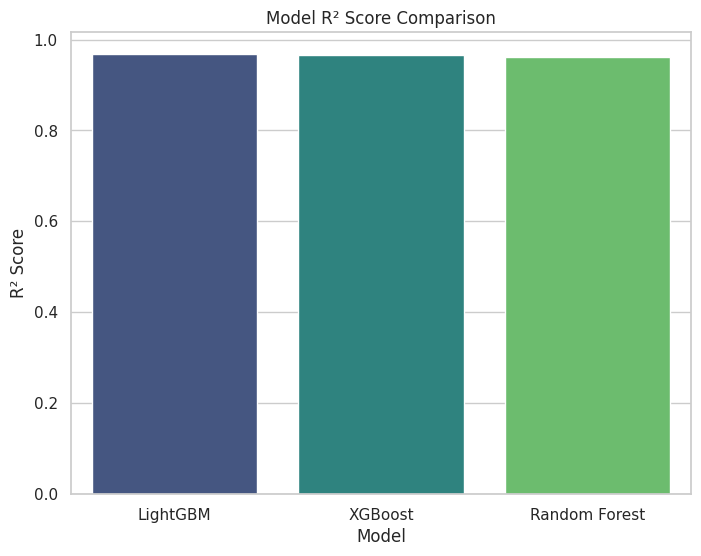

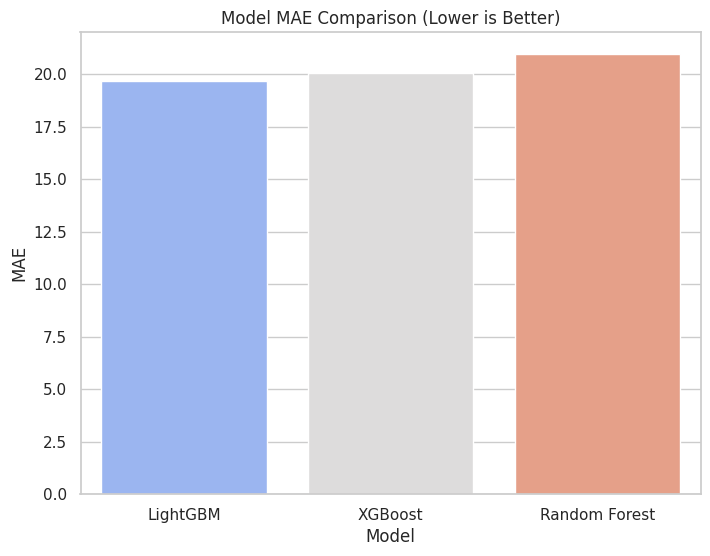

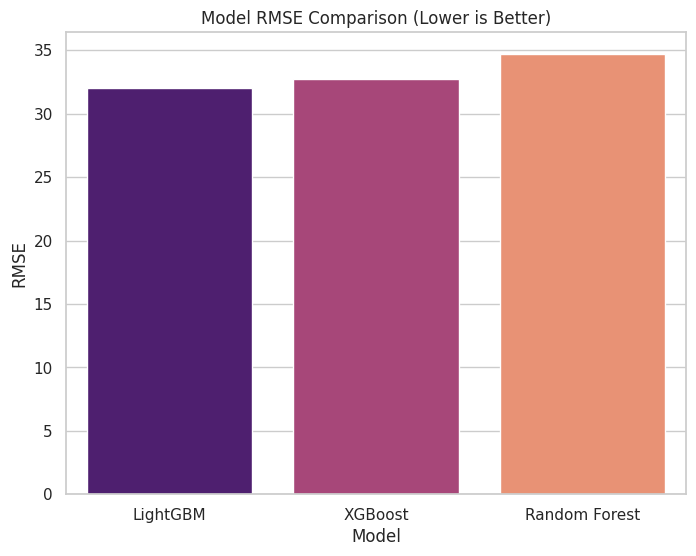

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R²"]).T
results_df = results_df.sort_values(by="R²", ascending=False)

print("\n📊 Model Comparison (Week 5):")
display(results_df)

# Plot R² scores
plt.figure(figsize=(8,6))
sns.barplot(
    x=results_df.index,
    y=results_df["R²"],
    hue=results_df.index,
    palette="viridis",
    legend=False
)
plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.show()

# Plot MAE scores
plt.figure(figsize=(8,6))
sns.barplot(
    x=results_df.index,
    y=results_df["MAE"],
    hue=results_df.index,
    palette="coolwarm",
    legend=False
)
plt.title("Model MAE Comparison (Lower is Better)")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()

# Plot RMSE scores
plt.figure(figsize=(8,6))
sns.barplot(
    x=results_df.index,
    y=results_df["RMSE"],
    hue=results_df.index,
    palette="magma",
    legend=False
)
plt.title("Model RMSE Comparison (Lower is Better)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.show()


Compare with Previous Best Models

In [ ]:
# Add previously tuned XGBoost and Random Forest (already trained as best_xgb, best_rf)
results_exp['Tuned Random Forest'] = evaluate_model(best_rf, X_train_exp, y_train_exp, X_test_exp, y_test_exp, "Tuned Random Forest")
results_exp['Tuned XGBoost'] = evaluate_model(best_xgb, X_train_exp, y_train_exp, X_test_exp, y_test_exp, "Tuned XGBoost")

# Convert to DataFrame
results_df_exp = pd.DataFrame(results_exp, index=["MAE", "RMSE", "R²"]).T
results_df_exp = results_df_exp.sort_values(by="R²", ascending=False)

print("📊 Model Performance Comparison (Week 5):")
display(results_df_exp)

Tuned Random Forest -> MAE: 20.31, RMSE: 32.94, R²: 0.9653
Tuned XGBoost -> MAE: 19.76, RMSE: 31.62, R²: 0.9680
📊 Model Performance Comparison (Week 5):


,MAE,RMSE,R²
Tuned XGBoost,19.756842,31.619243,0.967985
LightGBM,19.749699,31.694666,0.967832
Gradient Boosting,19.915184,31.699797,0.967822
Tuned Random Forest,20.314361,32.940539,0.965254
Neural Network,29.145904,43.179290,0.940297
